In [61]:
from argopy import DataFetcher
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load BGC dataset for float 4903622		
ds = DataFetcher(mode="expert", ds="bgc").float(4903622	).load().data

print("Variables:", list(ds.variables))

# Make sure time is in datetime format
time = pd.to_datetime(ds['TIME'].values)

# Create masks
surface_mask = ds['PRES'] <= 10  # Surface: <= 10 dbar
june_2025_mask = (time >= "2024-09-18") & (time < "2024-09-30")

# Apply both masks together
mask = surface_mask & june_2025_mask

# Get QC values for BBP700 at surface in June 2025
qc_surface = ds['BBP700_ADJUSTED_QC'].where(mask, drop=True)
qc_vals = np.array(qc_surface.values).astype(str)

# Summarize QC flags
unique, counts = np.unique(qc_vals, return_counts=True)
qc_summary = dict(zip(unique, counts))

print("QC flag summary for BBP700 near surface (<=10 dbar) in June 2025:")
for flag, cnt in qc_summary.items():
    print(f"QC={flag}: {cnt} points")

/opt/anaconda3/envs/earthaccess-env/lib/python3.11/site-packages/argopy/xarray.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  self._dims = list(xarray_obj.dims.keys())


Variables: ['BBP700', 'BBP700_ADJUSTED', 'BBP700_ADJUSTED_ERROR', 'BBP700_ADJUSTED_QC', 'BBP700_DATA_MODE', 'BBP700_QC', 'CHLA', 'CHLA_ADJUSTED', 'CHLA_ADJUSTED_ERROR', 'CHLA_ADJUSTED_QC', 'CHLA_DATA_MODE', 'CHLA_QC', 'CONFIG_MISSION_NUMBER', 'CYCLE_NUMBER', 'DIRECTION', 'DOXY', 'DOXY_ADJUSTED', 'DOXY_ADJUSTED_ERROR', 'DOXY_ADJUSTED_QC', 'DOXY_DATA_MODE', 'DOXY_QC', 'NITRATE', 'NITRATE_ADJUSTED', 'NITRATE_ADJUSTED_ERROR', 'NITRATE_ADJUSTED_QC', 'NITRATE_DATA_MODE', 'NITRATE_QC', 'PH_IN_SITU_TOTAL', 'PH_IN_SITU_TOTAL_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED_ERROR', 'PH_IN_SITU_TOTAL_ADJUSTED_QC', 'PH_IN_SITU_TOTAL_DATA_MODE', 'PH_IN_SITU_TOTAL_QC', 'PLATFORM_NUMBER', 'POSITION_QC', 'PRES', 'PRES_ADJUSTED', 'PRES_ADJUSTED_ERROR', 'PRES_ADJUSTED_QC', 'PRES_DATA_MODE', 'PRES_QC', 'PSAL', 'PSAL_ADJUSTED', 'PSAL_ADJUSTED_ERROR', 'PSAL_ADJUSTED_QC', 'PSAL_DATA_MODE', 'PSAL_QC', 'TEMP', 'TEMP_ADJUSTED', 'TEMP_ADJUSTED_ERROR', 'TEMP_ADJUSTED_QC', 'TEMP_DATA_MODE', 'TEMP_QC', 'TIME_QC', 'LATITUDE',

In [62]:
# Find indices where mask is True
matching_indices = np.where(mask)[0]

# Get the first matching profile's cycle number
first_cycle = ds['CYCLE_NUMBER'].values[matching_indices[0]]

print("Selected cycle:", first_cycle)

# Create mask for that specific profile (entire depth range, not just surface)
profile_mask = ds['CYCLE_NUMBER'] == first_cycle

# Extract data for that profile
profile_data = ds.where(profile_mask, drop=True)

print("Profile date:", pd.to_datetime(profile_data['TIME'].values[0]))
print("Variables in profile:", list(profile_data.variables))

Selected cycle: 110
Profile date: 2024-09-25 09:38:06.000999936
Variables in profile: ['BBP700', 'BBP700_ADJUSTED', 'BBP700_ADJUSTED_ERROR', 'BBP700_ADJUSTED_QC', 'BBP700_DATA_MODE', 'BBP700_QC', 'CHLA', 'CHLA_ADJUSTED', 'CHLA_ADJUSTED_ERROR', 'CHLA_ADJUSTED_QC', 'CHLA_DATA_MODE', 'CHLA_QC', 'CONFIG_MISSION_NUMBER', 'CYCLE_NUMBER', 'DIRECTION', 'DOXY', 'DOXY_ADJUSTED', 'DOXY_ADJUSTED_ERROR', 'DOXY_ADJUSTED_QC', 'DOXY_DATA_MODE', 'DOXY_QC', 'NITRATE', 'NITRATE_ADJUSTED', 'NITRATE_ADJUSTED_ERROR', 'NITRATE_ADJUSTED_QC', 'NITRATE_DATA_MODE', 'NITRATE_QC', 'PH_IN_SITU_TOTAL', 'PH_IN_SITU_TOTAL_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED_ERROR', 'PH_IN_SITU_TOTAL_ADJUSTED_QC', 'PH_IN_SITU_TOTAL_DATA_MODE', 'PH_IN_SITU_TOTAL_QC', 'PLATFORM_NUMBER', 'POSITION_QC', 'PRES', 'PRES_ADJUSTED', 'PRES_ADJUSTED_ERROR', 'PRES_ADJUSTED_QC', 'PRES_DATA_MODE', 'PRES_QC', 'PSAL', 'PSAL_ADJUSTED', 'PSAL_ADJUSTED_ERROR', 'PSAL_ADJUSTED_QC', 'PSAL_DATA_MODE', 'PSAL_QC', 'TEMP', 'TEMP_ADJUSTED', 'TEMP_ADJUSTED_ERRO

In [63]:
from datetime import datetime
import pytz

# Float metadata
lat = 24.797
lon = -93.388
utc_time_str = "2024-09-25 09:38:06"  # Profile date/time in UTC

# Parse the UTC timestamp
utc_dt = datetime.strptime(utc_time_str, "%Y-%m-%d %H:%M:%S")

# Timezones
utc_zone = pytz.utc
central_zone = pytz.timezone("US/Central")

# Localize to UTC first
utc_dt = utc_zone.localize(utc_dt)

# Convert to Central local time
local_dt = utc_dt.astimezone(central_zone)

print("UTC time:", utc_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))
print("Local time:", local_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))

UTC time: 2024-09-25 09:38:06 UTC
Local time: 2024-09-25 04:38:06 CDT


In [65]:
# Extract depth and BBP700 for the selected profile
depth = profile_data["PRES_ADJUSTED"].values
bbp700 = profile_data["BBP700_ADJUSTED"].values

# Some profiles may be stored 2D [n_profiles, n_levels]
# If so, take the first (and only) profile slice
if bbp700.ndim > 1:
    depth = depth[0, :]
    bbp700 = bbp700[0, :]

# Remove NaN values
mask = ~np.isnan(bbp700)
depth = depth[mask]
bbp700 = bbp700[mask]

print("Number of depth levels:", len(depth))
print("First 10 BBP700 values:", bbp700[:10])

Number of depth levels: 69
First 10 BBP700 values: [0.000483 0.000505 0.000539 0.000539 0.000561 0.000561 0.000638 0.000716
 0.000661 0.00065 ]


In [44]:
depth = profile_data["PRES_ADJUSTED"].values
bbp700 = profile_data["BBP700_ADJUSTED"].values

# Replace fill values with NaN
bbp700 = np.where(bbp700 > 1e4, np.nan, bbp700)

# Drop NaNs
valid_mask = ~np.isnan(bbp700)
depth = depth[valid_mask]
bbp700 = bbp700[valid_mask]

print("Number of valid BBP700 points:", len(bbp700))
print("First 10 valid values:", bbp700[:10])

Number of valid BBP700 points: 69
First 10 valid values: [0.000684 0.000761 0.00055  0.00055  0.000505 0.000661 0.000573 0.000739
 0.000661 0.000683]


In [66]:
# Use adjusted if available, otherwise raw
if np.isfinite(profile_data["PRES_ADJUSTED"].values).any():
    depth = profile_data["PRES_ADJUSTED"].values
else:
    depth = profile_data["PRES"].values

bbp700 = profile_data["BBP700_ADJUSTED"].values

# Mask bad BBP values
valid_mask = bbp700 < 1e4
depth_valid = depth[valid_mask]
bbp_valid   = bbp700[valid_mask]

for d, b in zip(depth_valid[:10], bbp_valid[:10]):
    print(f"Depth = {d:.1f} dbar, BBP700 = {b:.6f} m^-1")

Depth = 8.0 dbar, BBP700 = 0.000483 m^-1
Depth = 11.8 dbar, BBP700 = 0.000505 m^-1
Depth = 16.9 dbar, BBP700 = 0.000539 m^-1
Depth = 21.6 dbar, BBP700 = 0.000539 m^-1
Depth = 27.0 dbar, BBP700 = 0.000561 m^-1
Depth = 31.9 dbar, BBP700 = 0.000561 m^-1
Depth = 36.8 dbar, BBP700 = 0.000638 m^-1
Depth = 42.0 dbar, BBP700 = 0.000716 m^-1
Depth = 46.9 dbar, BBP700 = 0.000661 m^-1
Depth = 51.8 dbar, BBP700 = 0.000650 m^-1


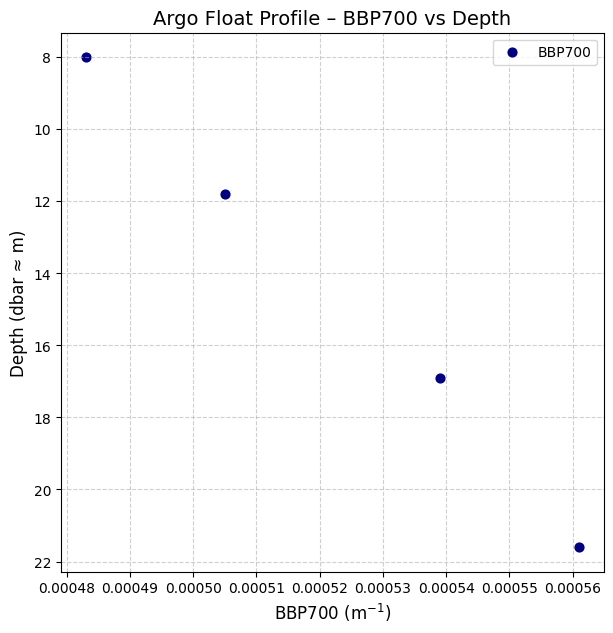

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Example: your extracted values (replace with your full arrays)
depths = np.array([8.0, 11.8, 16.9, 21.6])
bbp700 = np.array([0.000483, 0.000505, 0.000539, 0.000561])

# Plot as scatter points only
plt.figure(figsize=(7,7))
plt.scatter(bbp700, depths, color='navy', s=40, label="BBP700")

# Flip y-axis so surface is at top
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("BBP700 (m$^{-1}$)", fontsize=12)
plt.ylabel("Depth (dbar ≈ m)", fontsize=12)
plt.title("Argo Float Profile – BBP700 vs Depth", fontsize=14)

# Add grid + legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()